In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from math import sqrt
import time
import re
from scipy import signal
import ipywidgets as widgets
from src.analisi.tools import *

In [2]:
%matplotlib widget
plt.close('all')

In [3]:
# selettore cartella
folder_selector = widgets.Dropdown( 
    options=sorted([f for f in os.listdir(base_img_folder) if os.path.isdir(os.path.join(base_img_folder, f))], reverse=True),
    description='Sessione:',
    style={'description_width': 'initial'}
)

display(folder_selector)

Dropdown(description='Sessione:', options=('percolazione', 'lampadina_test_final', 'lampadina3_test', 'lampadi…

In [4]:
bilancia_timestamps, thicknesses, rates = load_bilancia_data(os.path.join(base_img_folder, folder_selector.value, 'data/points.txt'))

bilancia_timestamps = np.array(bilancia_timestamps)
bilancia_trel = bilancia_timestamps - bilancia_timestamps[0]

print(max(bilancia_trel))

1690.033730506897


In [5]:
#raccolgiamo le immagini per calcolare le intensità medie 

images, image_timestamps = load_images_from_folder(os.path.join(base_img_folder, folder_selector.value, 'images'))
images, image_timestamps = sort_images_and_timestamps(images, image_timestamps)

image_seconds = [time.mktime(time.strptime(ts, FORMATO_COMUNE)) for ts in image_timestamps]
image_seconds = np.array(image_seconds)

image_trel = image_seconds - image_seconds[0]

In [6]:
# ((384, 292), 60)

roi = {
    "center": (383, 310),  # posizione centrale del ROI
    "radius": 60       # dimensione del ROI
}

In [7]:
roi_center = roi['center']
roi_radius = roi['radius']

reference_image = np.median(images[:10], axis=0).astype(np.uint8) if images else None
roi_images = extract_roi_from_images(images, roi_center, roi_radius)
reference_image_roi = extract_roi_from_images([reference_image], roi_center, roi_radius)[0]
difference_images = compute_difference_from_reference(roi_images, reference_image_roi)

In [8]:
window_size = 60
slope = 5.6145
intercept = 0.0312

sigma = window_size / 2
images_smooth = moving_average_images_gaussian_weights(difference_images, window_size, sigma)
mean_intensities = np.mean(images_smooth, axis=(1, 2))
#[np.mean(img) for img in images_smooth]

fitted_thicknesses = slope * np.array(mean_intensities) + intercept

In [9]:
print(np.max(fitted_thicknesses), np.min(fitted_thicknesses))

9.024543383789062 0.114942314453125


In [10]:
elettrometro_dir = os.path.join(base_img_folder, folder_selector.value, 'data/points_keithley.txt')

In [11]:
keithley_currents, keithley_timestamps, keithley_ranges = load_keithley_data(elettrometro_dir)

keithley_currents = np.array(keithley_currents)
keithley_timestamps = np.array(keithley_timestamps)
keithley_trel = keithley_timestamps - keithley_timestamps[0]

print(max(keithley_trel))

4187.232023


In [12]:
auto_range_indices = np.array([i for i, r in enumerate(keithley_ranges) if r == -1])
plus2_inds = auto_range_indices - 1
plus1_inds = auto_range_indices - 2


elettrometro_series = {
    "auto": (keithley_trel[auto_range_indices], keithley_currents[auto_range_indices]),
    "+2": (keithley_trel[plus2_inds], keithley_currents[plus2_inds]),
    "+1": (keithley_trel[plus1_inds], keithley_currents[plus1_inds])
}


In [ ]:
# interpolazione correnti sui timestamp della bilancia
elettrometro_series_interpolated = {}

start_time = 0
#finish_time = 2100 #lo attivo se voglio cercare lo spessore di percolazione perché il fit va fatto solo nei pressi dello spessore critico


for key, (t_rel, currents) in elettrometro_series.items():

    # select only data points where t >= start_time

    mask_elettrometro = (t_rel >= start_time) #& (t_rel <= finish_time)
    mask_camera = (image_trel >= start_time) #& (image_trel <= finish_time)

    t_rel_cut = t_rel[mask_elettrometro]
    currents_cut = currents[mask_elettrometro]

    image_trel_masked = image_trel[mask_camera]
    
    interpolated_currents = np.interp(image_trel_masked, t_rel_cut, currents_cut)
    
    elettrometro_series_interpolated[key] = (image_trel_masked, interpolated_currents)
    
    interpolated_res = calculate_resistance(np.array(interpolated_currents), 0.5)

    print(len(image_trel_masked), len(interpolated_currents), len(interpolated_res))


4240 4240 4240
4240 4240 4240
4240 4240 4240


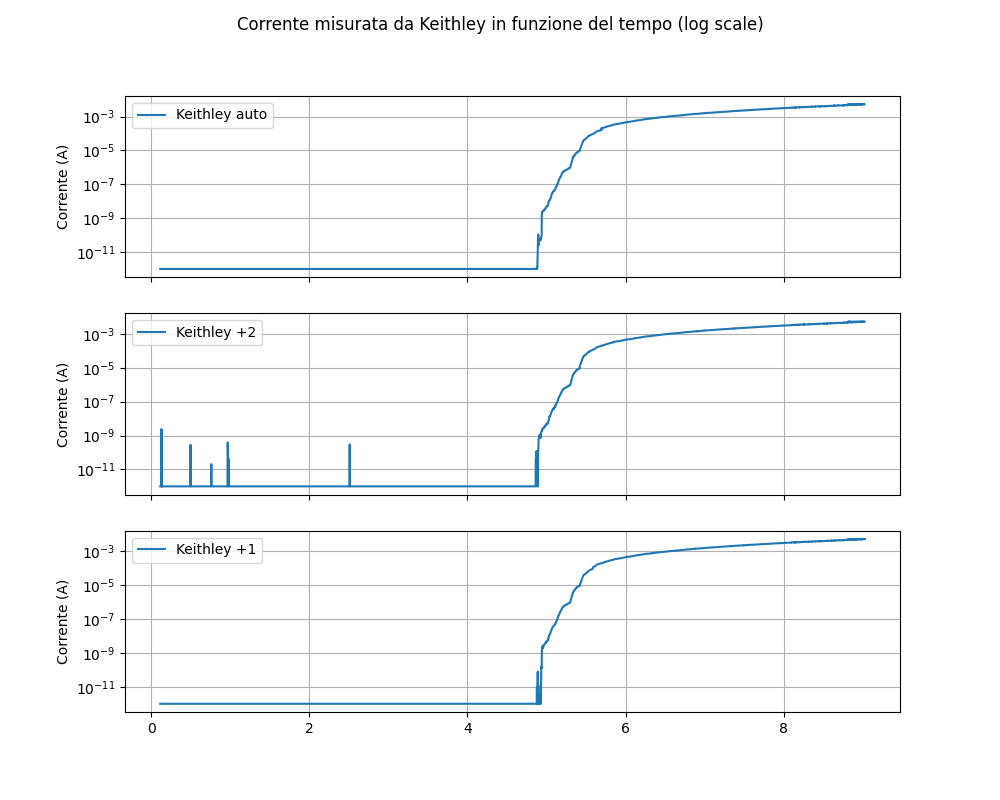

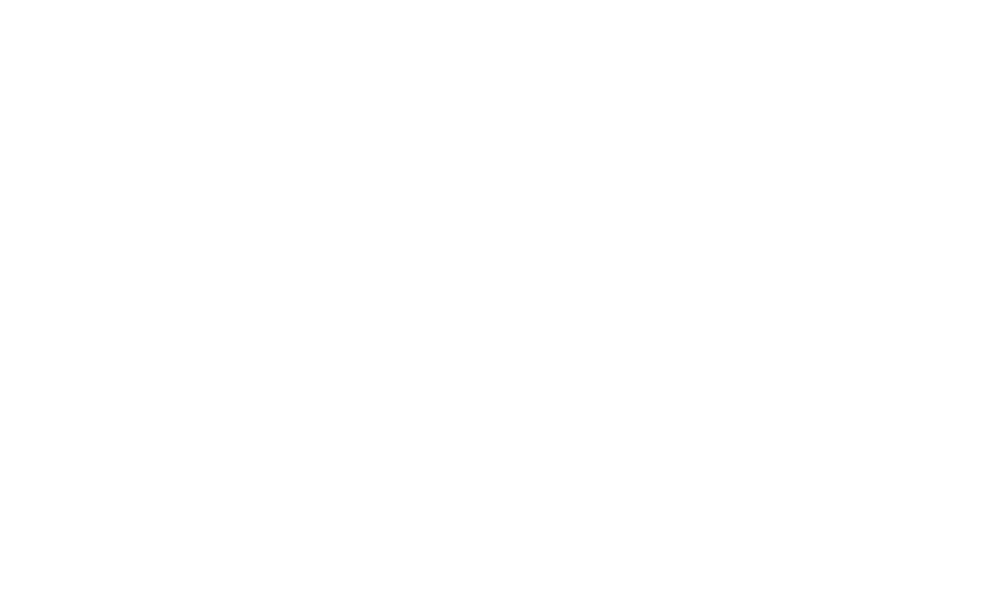

In [111]:
plt.figure(figsize=(10, 6))

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 8))

fig.suptitle('Corrente misurata da Keithley in funzione del tempo (log scale)')


for ax, (key, val) in zip(axes, elettrometro_series_interpolated.items()):

    t, curr = val

    less_than_zero_mask = curr < 0
    curr[less_than_zero_mask] = 0

    reasonableness_mask = (curr > 1e-12) & (curr < 1e2)
    curr[~reasonableness_mask] = 0

    zero_mask = curr == 0
    curr[zero_mask] = 1e-12

    ax.plot(fitted_thicknesses[mask_camera], curr, label=f'Keithley {key}', marker='', linestyle='-', markersize=4)

    #ax.plot(fitted_thicknesses, interpolated_currents, label=f'Keithley {key}', marker='', linestyle='-', markersize=4)
    ax.set_yscale('log')
    ax.set_ylabel('Corrente (A)')
    ax.legend()
    ax.grid(True)
    #ax.set_ylim(np.min(curr), np.max(curr))

plt.show()

AttributeError: 'int' object has no attribute 'scatter'

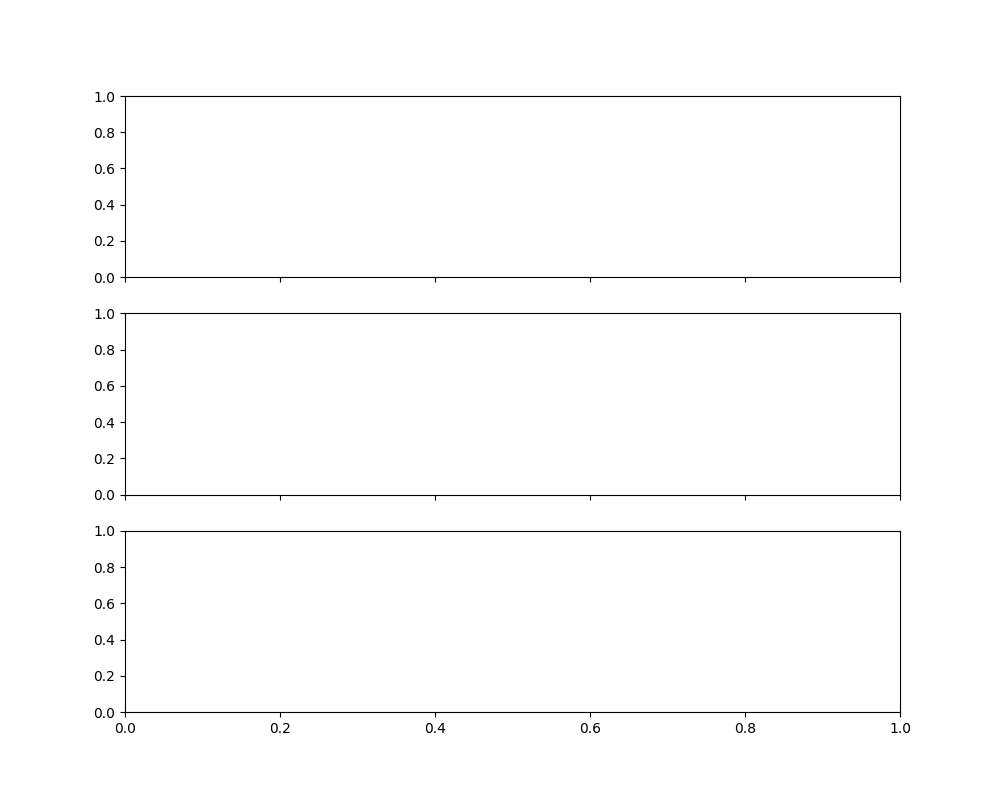

In [ ]:
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 8))

# disegna la curva percolativa con le resistenze in funzione dei fitted_thicknesses
# le resistenze dipendono dalla serie di corrente identificata dal key del range
# gli spessori son fittati e sono indipendenti dalla serie di corrente

for i in range(len(axes)):
    ax.scatter(fitted_thicknesses[mask_camera], interpolated_res, label=f'Keithley {key}')
    ax.set_ylabel('Resistenza (Ω)')
    ax.set_xlabel('Spessore')
    ax.set_yscale('log')
    ax.legend()
    axes[i].grid(True)
    

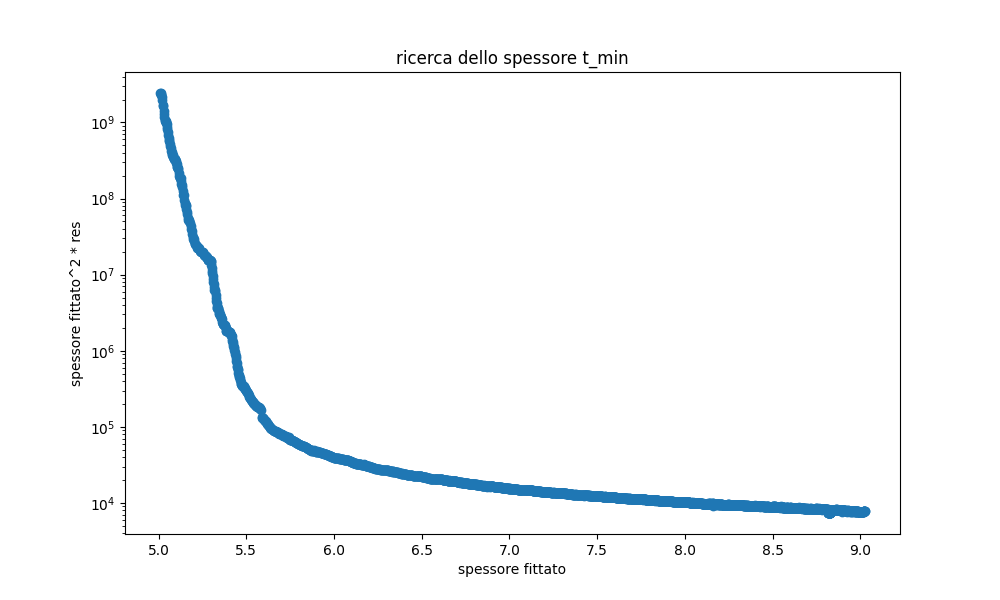

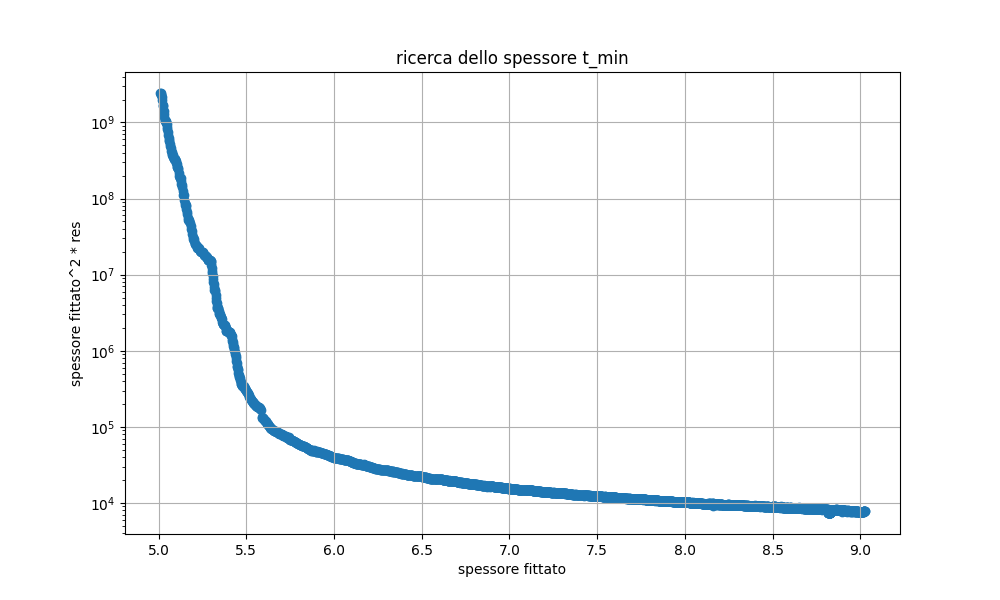

In [ ]:
# ricerca dello spessore t_min, passaggio da percolativo a ohmico (il campione ha formato uno strato continuo oltre la percolazione)


Rt2 = [r * (t**2) for r, t in zip(interpolated_res, fitted_thicknesses[mask_camera])]

plt.figure(figsize=(10, 6))
plt.scatter(fitted_thicknesses[mask_camera], Rt2)
plt.xlabel('spessore fittato')
plt.ylabel('spessore fittato^2 * res')
plt.yscale('log')
plt.title('ricerca dello spessore t_min')
plt.show()
plt.grid(True)
plt.show()

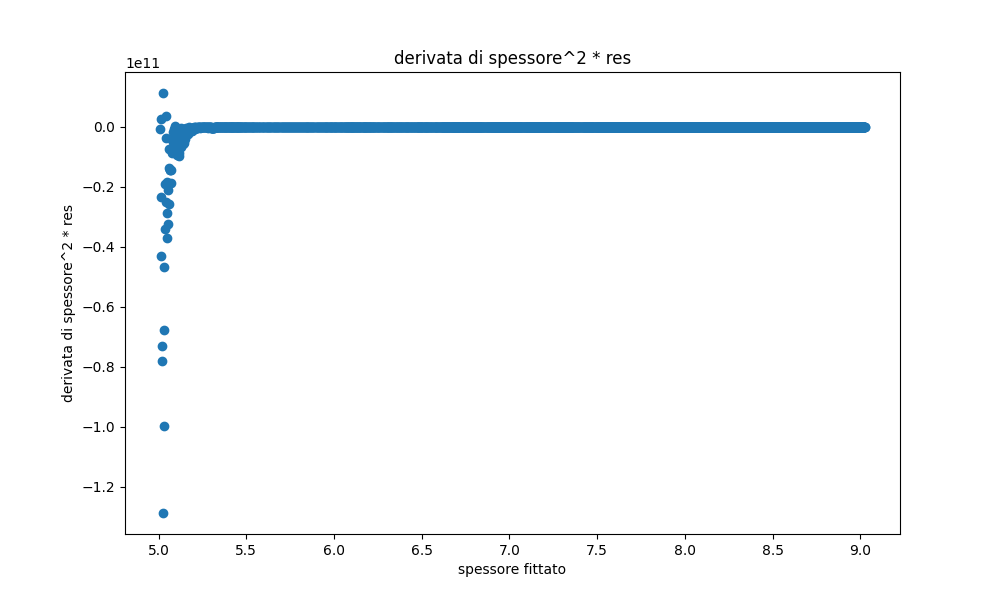

In [102]:
deltax = []
deltat = []

Rt2 = [r * (t**2) for r, t in zip(interpolated_res, fitted_thicknesses[mask_camera])]

for i in range(len(interpolated_res)):
    deltat.append(fitted_thicknesses[mask_camera][i] - fitted_thicknesses[mask_camera][i-1])
    deltax.append(Rt2[i] - Rt2[i-1])
    
derivata = [dx/dt for dx, dt in zip(deltax, deltat)]

plt.figure(figsize=(10, 6))
plt.scatter(fitted_thicknesses[mask_camera], derivata)
plt.xlabel('spessore fittato')
plt.ylabel('derivata di spessore^2 * res')
plt.title('derivata di spessore^2 * res')
#plt.yscale('log')
plt.show()
plt.grid(True)

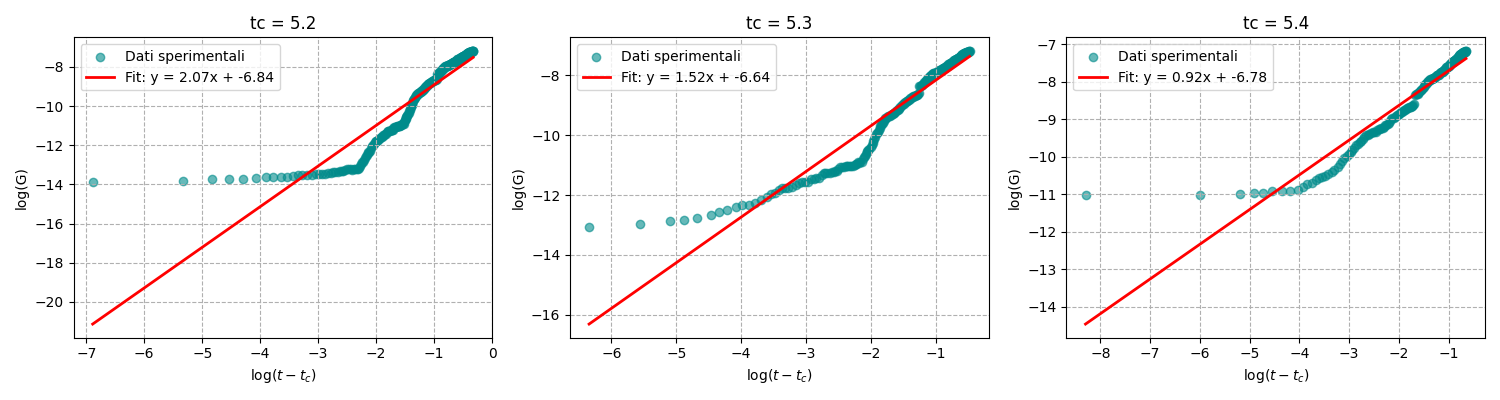

In [95]:
# ricerca dello spessore di percolazione t_c (spessore critico)

step = 0.1
tc= np.arange(5.2, 5.4+step, step)

logG = np.log(1/interpolated_res)



fig, ax = plt.subplots(1, len(tc), figsize=(15, 4))



for j, t in enumerate(tc):
    diff = fitted_thicknesses[mask_camera] - t
    valid_mask = diff > 0
    log_t_tc = np.log(diff[valid_mask])
    logG_filtered = logG[valid_mask]
    m, q = np.polyfit(log_t_tc, logG_filtered, 1)
    y_fit = m * log_t_tc + q
    ax[j].scatter(log_t_tc, logG_filtered, alpha=0.6, label="Dati sperimentali", color="darkcyan")
    ax[j].plot(log_t_tc, y_fit, color="red", lw=2, label=f"Fit: y = {m:.2f}x + {q:.2f}")
    ax[j].set_title(f'tc = {tc[j]:.1f}')
    ax[j].set_xlabel("log($t - t_c$)")
    ax[j].set_ylabel('log(G)')
    ax[j].grid(True, which="both", ls="--")
    ax[j].legend()
plt.tight_layout()
plt.show()

 

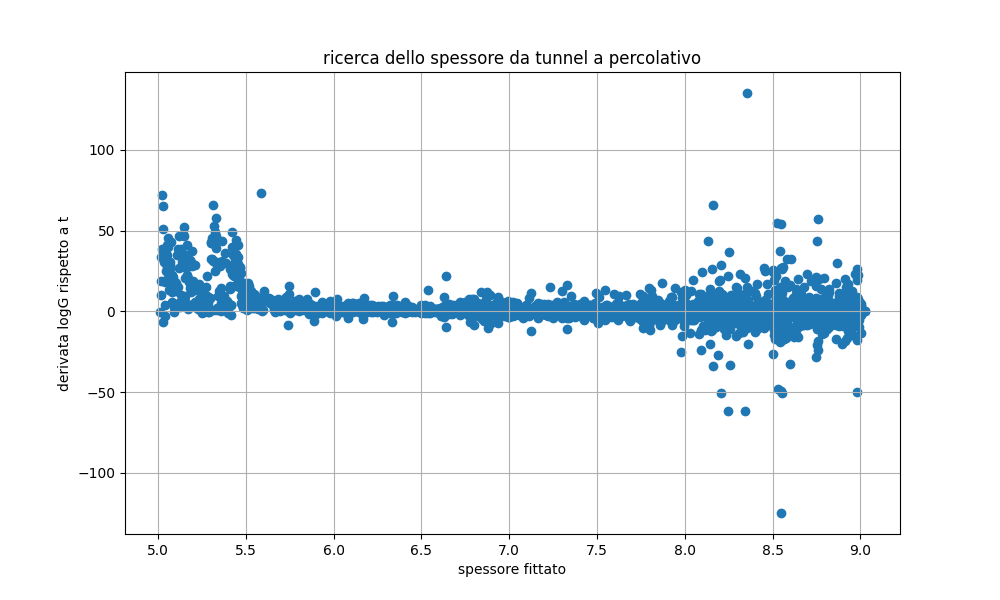

In [104]:
# ricerca dello spessore da tunnel a percolativo, è il massimo della derivata di logG rispetto a t


deltaG = []
deltat = []

logG = np.log(1/interpolated_res)

for i in range(1, len(logG)):
    deltaG.append(logG[i] - logG[i-1])
    deltat.append(fitted_thicknesses[mask_camera][i] - fitted_thicknesses[mask_camera][i-1])
    
derivata = np.array(deltaG) / np.array(deltat)


plt.figure(figsize=(10, 6))
plt.scatter(fitted_thicknesses[mask_camera][1:], derivata)
plt.xlabel('spessore fittato')
plt.ylabel('derivata logG rispetto a t')
plt.title('ricerca dello spessore da tunnel a percolativo')
plt.grid(True)
plt.show()